In [1]:
%pip install numpy pandas seaborn matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
df= pd.read_csv("sugurta.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

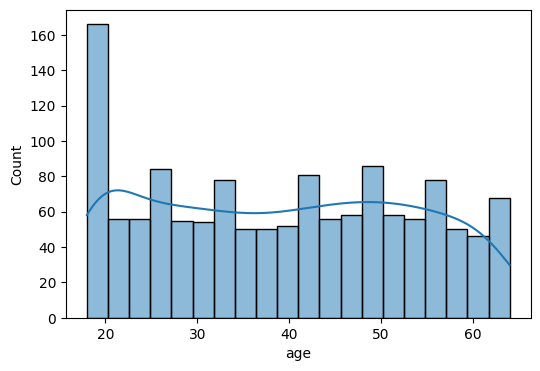

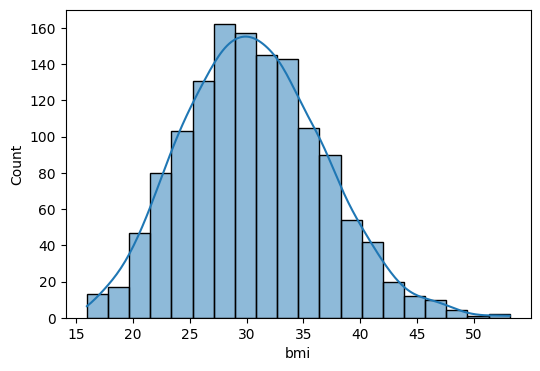

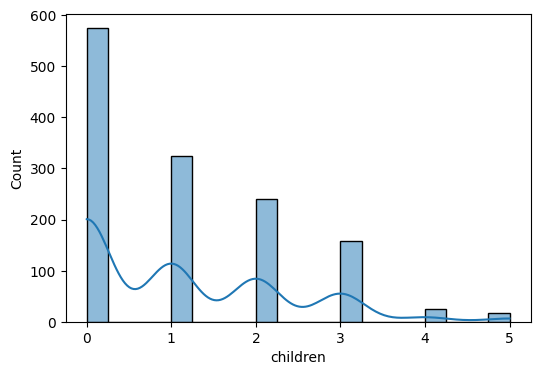

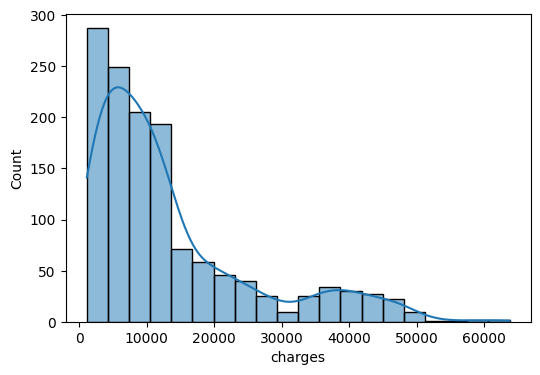

In [8]:
numeric_columns=['age', 'bmi','children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

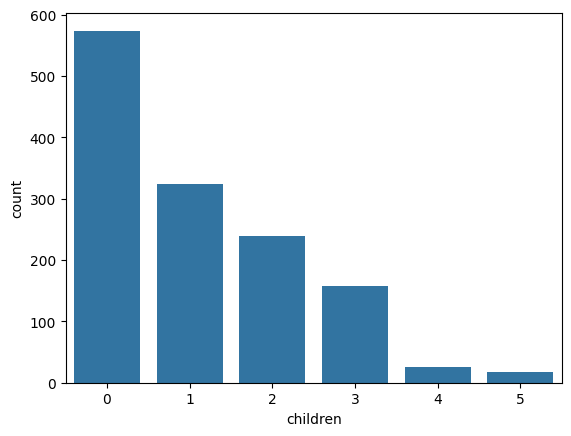

In [9]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

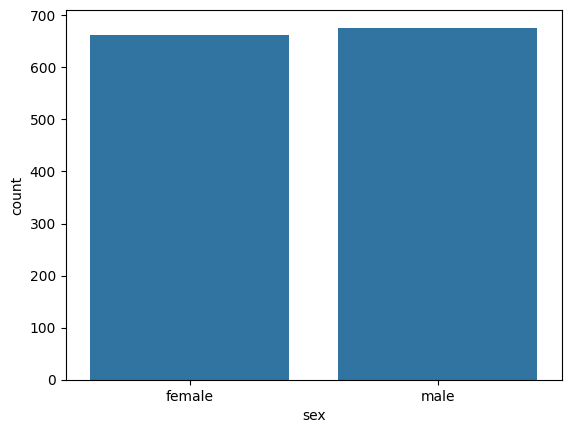

In [10]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

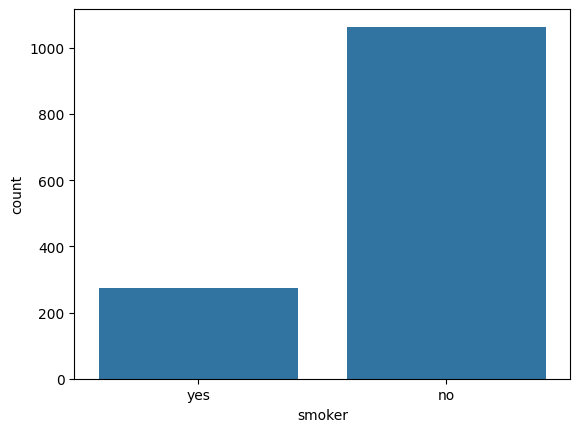

In [11]:
sns.countplot(x=df['smoker'])

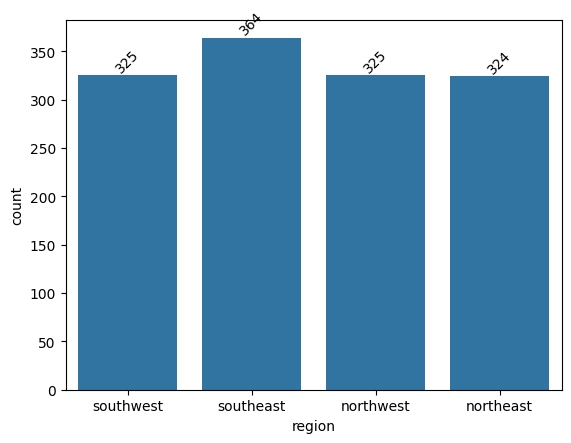

In [12]:
ax=sns.countplot(x=df['region'])
ax.bar_label(ax.containers[0],fmt='%.0f', rotation=45)
plt.show()

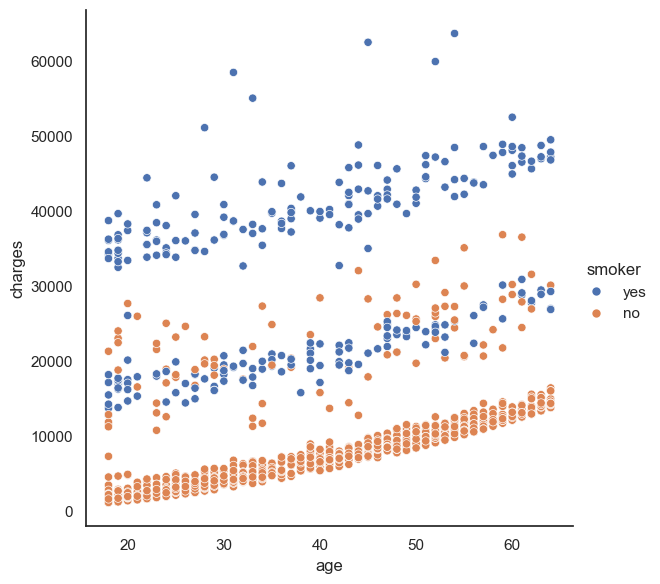

In [13]:
sns.set_theme(style="white")
sns.relplot( data=df,
            x="age", y="charges",
            hue="smoker",
            height=6)

<Axes: >

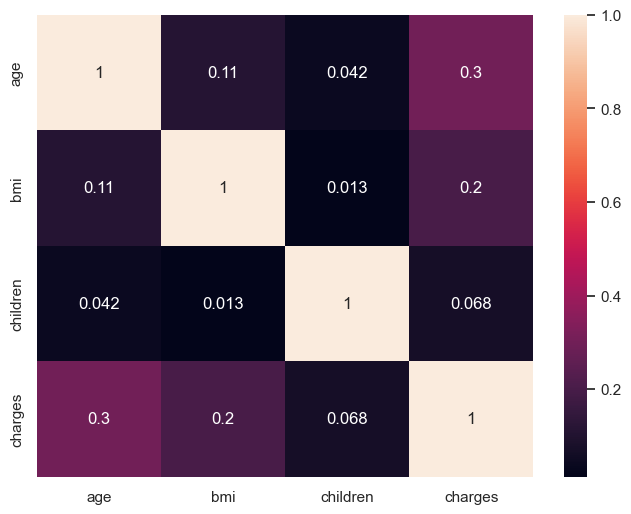

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

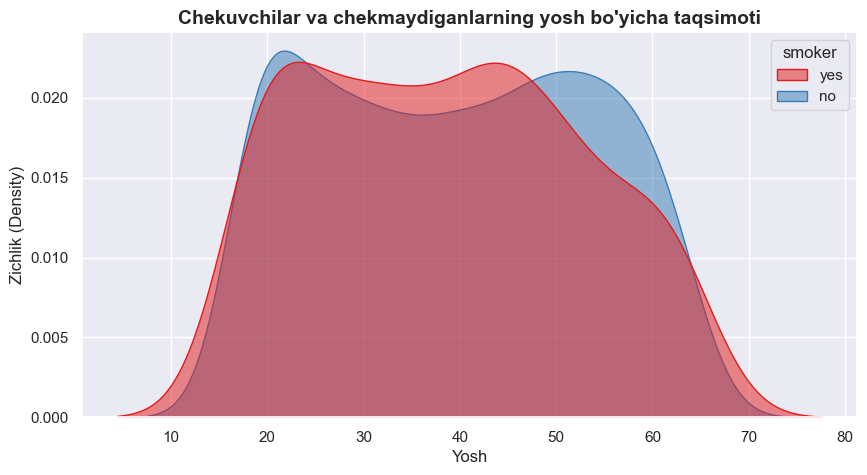

In [15]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df, x="age", hue="smoker", fill=True, common_norm=False, palette="Set1", alpha=0.5)

plt.title("Chekuvchilar va chekmaydiganlarning yosh bo'yicha taqsimoti", fontsize=14, fontweight='bold')
plt.xlabel("Yosh", fontsize=12)
plt.ylabel("Zichlik (Density)", fontsize=12)
plt.show()

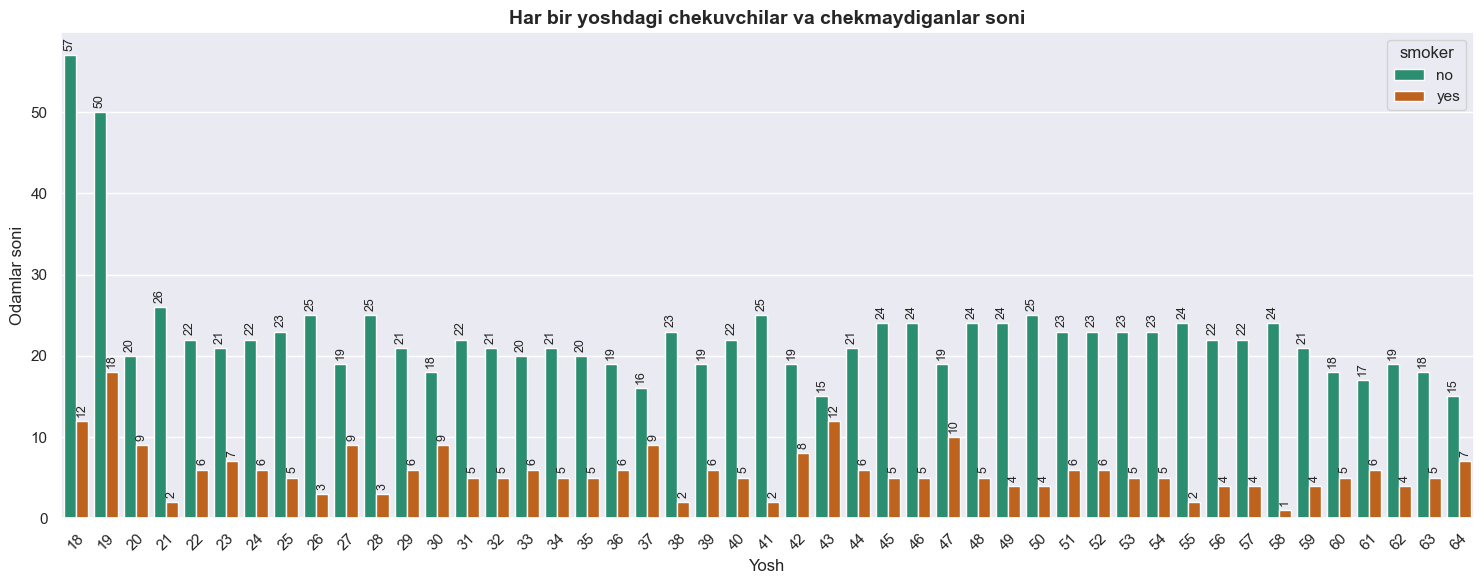

In [16]:
plt.figure(figsize=(15, 6))

# Ustunli grafik chizish
ax = sns.countplot(data=df, x="age", hue="smoker", palette="Dark2")

# Avvalgi darsda o'rganganimizdek, yozuvlarni chiroyli ko'rsatish
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', rotation=90, padding=3, fontsize=9)

plt.title("Har bir yoshdagi chekuvchilar va chekmaydiganlar soni", fontsize=14, fontweight='bold')
plt.xlabel("Yosh", fontsize=12)
plt.ylabel("Odamlar soni", fontsize=12)
plt.xticks(rotation=45) # X o'qidagi yoshlarni sal burib qo'yamiz
plt.tight_layout()
plt.show()

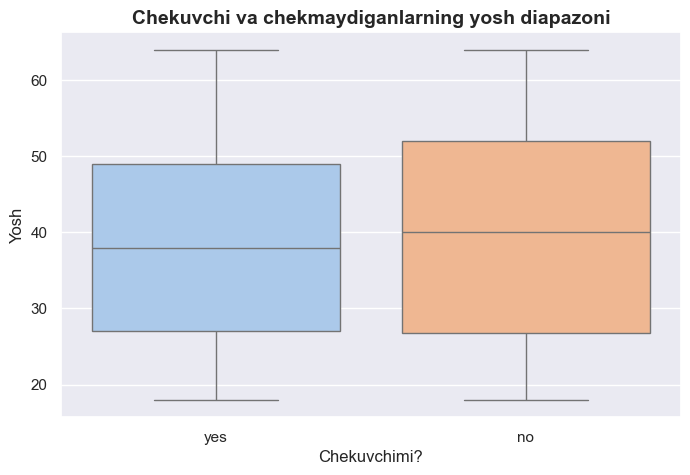

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="smoker", y="age", palette="pastel")

plt.title("Chekuvchi va chekmaydiganlarning yosh diapazoni", fontsize=14, fontweight='bold')
plt.xlabel("Chekuvchimi?", fontsize=12)
plt.ylabel("Yosh", fontsize=12)
plt.show()

In [18]:
df_cleaned=df.copy()

In [19]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [20]:
df_cleaned.shape

(1338, 7)

In [21]:
df_cleaned.drop_duplicates(inplace=True)

In [22]:
df_cleaned.shape

(1337, 7)

In [23]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
df_cleaned.dtypes


age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [25]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [26]:
df_cleaned['sex']=df_cleaned['sex'].map({"male":0,"female":1})

In [27]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [28]:
df_cleaned['smoker']=df_cleaned['smoker'].map({"yes":1,"no":0})

In [29]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [30]:
df_cleaned.rename(columns={'sex':'is_female',
                          'smoker':'is_smoker'},inplace=True)

In [31]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [32]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [33]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [34]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [35]:
df_cleaned=df_cleaned.astype(int)

In [36]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [37]:
# feaute engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

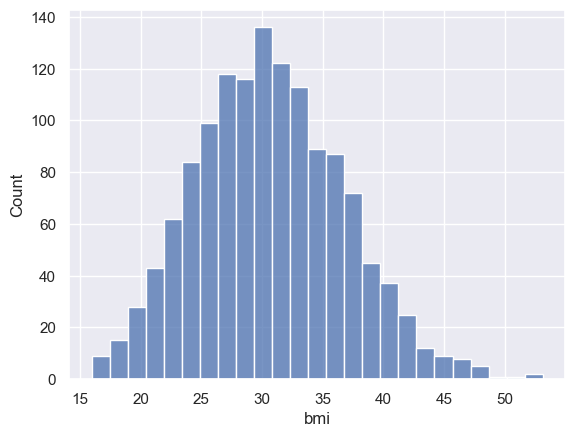

In [38]:
sns.histplot(df['bmi'])

In [39]:
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],
                                 bins=[0,18.5,24.9,29.9,float('inf')],
                                 labels=['Underweight','Normal','overweight','obese'])

In [40]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese
1334,18,1,31,0,0,2205,0,0,0,obese
1335,18,1,36,0,0,1629,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,1,overweight


In [41]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [42]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [43]:
df_cleaned=df_cleaned.astype(int)

In [44]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [45]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [46]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [47]:
# pearson correlation calculation- qiymatlar urtasidagi bogliqlik

In [48]:
from scipy.stats import pearsonr

In [49]:
selected_features=['age','bmi','children','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_overweight',
                   'bmi_category_obese']

In [50]:
correlations={feature:pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
             for feature in selected_features}

In [51]:
correlation_df=pd.DataFrame(list(correlations.items()),
                             columns=['Feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
3,is_smoker,0.787234
0,age,0.298309
9,bmi_category_obese,0.200348
1,bmi,0.196236
5,region_southeast,0.073577
2,children,0.067390
4,region_northwest,-0.038695
6,region_southwest,-0.043637
7,bmi_category_Normal,-0.104042
8,bmi_category_overweight,-0.120601


In [52]:
cat_features='is_female','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_overweight',
'bmi_category_obese'

'bmi_category_obese'

In [53]:
from scipy.stats import chi2_contingency
alpha=0.05

In [54]:
df_cleaned['charges_bin']=pd.qcut(df_cleaned['charges'], q=4, labels=False)

In [55]:
chi2_results={}

In [56]:
for col in cat_features:
    contingency=pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val,_,_=chi2_contingency(contingency)
    decision='Reject Null(Keep Feature)' if p_val<alpha else 'Accept Null(Drop Feature)'
    chi2_results[col]={'chi2_statistic':chi2_stat, 'p_value':p_val,'Decision':decision}

In [57]:
chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null(Keep Feature)
region_southeast,15.998167,0.001135,Reject Null(Keep Feature)
is_female,10.258784,0.01649,Reject Null(Keep Feature)
region_southwest,5.091893,0.165191,Accept Null(Drop Feature)
bmi_category_overweight,4.25149,0.235557,Accept Null(Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null(Drop Feature)
region_northwest,1.13424,0.768815,Accept Null(Drop Feature)


In [58]:
final_df=df_cleaned[[
    'age','bmi','children','is_female','is_smoker', 'charges',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_overweight','bmi_category_obese'
]]
final_df

,age,bmi,children,is_female,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0,1,0,1,0
1,-1.511647,0.462463,-0.079442,0,0,1725,0,1,0,0,0,1
2,-0.799350,0.462463,1.580143,0,0,4449,0,1,0,0,0,1
3,-0.443201,-1.334960,-0.909234,0,0,21984,1,0,0,1,0,0
4,-0.514431,-0.354547,-0.909234,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,10600,1,0,0,0,0,1
1334,-1.511647,0.135659,-0.909234,1,0,2205,0,0,0,0,0,1
1335,-1.511647,0.952670,-0.909234,1,0,1629,0,1,0,0,0,1
1336,-1.297958,-0.844753,-0.909234,1,0,2007,0,0,1,0,1,0


In [59]:
# chi2_-- bu chi kvadrat pearson koefisiyentiga uxshagan bogliqlikni topadi farqi kategoriyali ustunlarni bog'liqligini samaraliroq topadi
# pearson sonli ustunlarda yaxshi ishlaydi
# pearsonda bog'liqlikni 1-<1 oraliqda , chi2 da esa statistikava p_value bilan kursatadi, chi2 musbat va manfiyga bulmaydi, bog'liqlik bor yoki yuqligini aniqlaydi, pearson esa bog'liqik
# darajasini belgilaydi

In [60]:
# train va test 29.07.2026
X=final_df.drop('charges', axis=1)
y=final_df['charges']


In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [62]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=300,max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
print("model muvaffaqiyatli o'qitildi")

model muvaffaqiyatli o'qitildi


In [63]:
# test qilib tekshiramiz, yangi mijoz ma'lumotlarini kiritamiz
yangi_mijoz=pd.DataFrame(
    [{'age':-0.5,
     'bmi':0.2,
     'children':0.0,
     'is_female':0,
     'is_smoker':1,
     'region_northwest':0,
     'region_southeast':1,
     'region_southwest':0,
    'bmi_category_Normal':0,
     'bmi_category_overweight':0,
     'bmi_category_obese':1}]
)
yangi_mijoz=yangi_mijoz[X.columns]
taxminiy_charge=rf_model.predict(yangi_mijoz)
print(f"Taxmin qilingan sug'urta xarajati: ${taxminiy_charge[0]:.2f}")

Taxmin qilingan sug'urta xarajati: $41589.84


In [64]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)
pred=rf_model.predict(X_test)
mae=mean_absolute_error(y_test, pred)
mse=mean_squared_error(y_test,pred)
roots=mae**0.5
r2=r2_score(y_test,pred)
print(" mean absolute error",mae)
print(" mean squared error",mse)
print(" root error",roots)
print(" R2", r2)

 mean absolute error 2694.2208502174194
 mean squared error 21612462.220648196
 root error 51.90588454325212
 R2 0.8823850529470751


In [65]:
rf_model.fit(X_train,y_train)
pred=rf_model.predict(X_test)

In [66]:
natija=pd.DataFrame({
    "Actual": y_test,
    "Predicted":pred
})
natija["Error"]=natija["Actual"]-natija["Predicted"]
print(natija)

      Actual     Predicted        Error
900     8688   8847.849092  -159.849092
1064    5708  10496.659187 -4788.659187
1256   11436  13567.542184 -2131.542184
298    38746  42881.503876 -4135.503876
237     4463   5645.066153 -1182.066153
...      ...           ...          ...
534    13831  14240.451735  -409.451735
542    13887  14172.999183  -285.999183
760     3925   8049.880451 -4124.880451
1284   47403  48163.158581  -760.158581
1285    8534  15862.625012 -7328.625012

[268 rows x 3 columns]


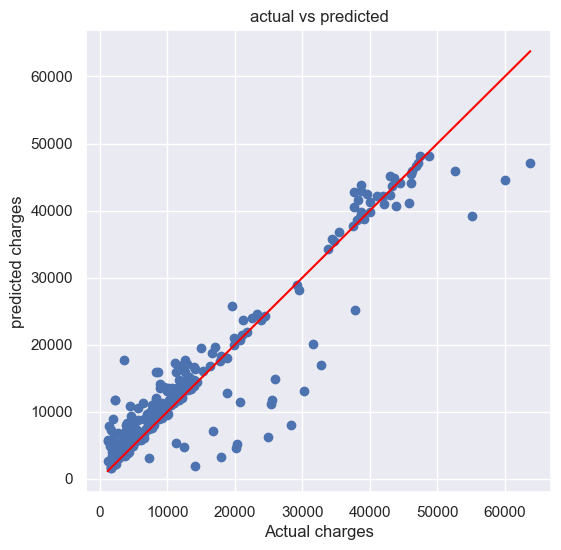

In [67]:
import matplotlib.pyplot as plt
plt.figure (figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual charges")
plt.ylabel("predicted charges")
plt.title("actual vs predicted")
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)
plt.show()

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import ( RandomForestRegressor,
GradientBoostingRegressor)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
}

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test, pred)

    print(f"{name}: r2 = {score:.4f}")

Linear Regression: r2 = 0.8047
Decision Tree: r2 = 0.7441
Random Forest: r2 = 0.8767
Gradient Boosting: r2 = 0.8938
KNN: r2 = 0.6422


In [70]:
from sklearn.model_selection import GridSearchCV
parametrlar={
    'n_estimators':[100,200,300],
    'learning_rate':[0.01, 0.05, 0.1],
    'max_depth': [2,3,4]
}
qidiruv=GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=parametrlar,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
qidiruv.fit(X_train, y_train)
print("eng yaxshi parametrlar: ", qidiruv.best_params_)
print(f"eng yaxshi R2 (cross-validation): {qidiruv.best_score_:.4f}")


eng yaxshi parametrlar:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
eng yaxshi R2 (cross-validation): 0.8453


In [72]:
eng_yaxshi_model=qidiruv.best_estimator_
bashorat=eng_yaxshi_model.predict(X_test)
r2=r2_score(y_test,bashorat)
print(f"sozlangan model test to'plamida R2: {r2:.4f}")
from sklearn.model_selection import cross_val_score
cv_natijalar=cross_val_score(eng_yaxshi_model, X,y,cv=5,scoring='r2')
print("har bir bulakdagi R2 natijalari: ", cv_natijalar)
print(f"o'rtacha f2: {cv_natijalar.mean():.4f}(+/- {cv_natijalar.std():.4f})")

sozlangan model test to'plamida R2: 0.9012
har bir bulakdagi R2 natijalari:  [0.88445499 0.80588878 0.89474615 0.85430243 0.87013388]
o'rtacha f2: 0.8619(+/- 0.0311)


In [76]:
def sugurta_narxini_bashorat_qil(yosh, bmi, farzandlar_soni, ayolmi,chekadimi,hudud,model,scaler, ustunlar):
    """ 
    yosh,bmi,farz_soni -> haqiqiy qiyatlar(28,27.5,1)
    ayolmi,chekadimi -> true/false yoki 1/0
    hudud  -> 'norwest','southwest','southeast','northeast'
    """
    if bmi<18.5:
        bmi_kategory='Underweight'
    elif bmi<25:
        bmi_kategory='Normal'
    elif bmi<30:    
        bmi_kategory='overweight'
    else:
        bmi_kategory='obese'
    yangi_mijoz=pd.DataFrame([{
       'age': yosh,
        'bmi': bmi,
        'children': farzandlar_soni,
        'is_female': int(ayolmi),
        'is_smoker':int(chekadimi),
        'region_northwest': 1 if hudud=='northwest' else 0,
        'region_southeast': 1 if hudud=='southeast' else 0,
        'region_southwest': 1 if hudud=='southwest' else 0,
        'bmi_category_Normal': 1 if bmi_kategory=='Normal' else 0,
        'bmi_category_overweight': 1 if bmi_kategory=='Overweight' else 0,
        'bmi_category_obese': 1 if bmi_kategory=='Obese' else 0,
    
    }])

    yangi_mijoz[['age','bmi','children']]=scaler.transform(
        yangi_mijoz[['age','bmi','children']]
    )
    yangi_mijoz=yangi_mijoz[ustunlar]
    natija=model.predict(yangi_mijoz)
    return natija[0]

misol_narx=sugurta_narxini_bashorat_qil(
    yosh=28,bmi=32.5,farzandlar_soni=1,
    ayolmi=0,chekadimi=1,hudud='southeast',
    model=eng_yaxshi_model, scaler=scaler, ustunlar=X.columns
)
print(f"taxmin qilingan sugurta xarajati: $ {misol_narx:.2f}")

taxmin qilingan sugurta xarajati: $ 30850.92


In [77]:
import joblib
import pandas as pd
joblib.dump(eng_yaxshi_model,'sugurta_modeli.pkl')
joblib.dump(scaler,'scaler.pkl')
print("Model 'sugurta_modeli.pkl' va scaler 'scaler.pkl' fayllariga saqlandi!")

Model 'sugurta_modeli.pkl' va scaler 'scaler.pkl' fayllariga saqlandi!
